# 🚀 Tutorial 1: Time-Resolved Decoding with HeteroRC

Welcome to the foundational tutorial for **HeteroRC (Heterogeneous Reservoir Computing)**! 

Conventional neural decoding pipelines often rely on linear classifiers applied to instantaneous signal amplitudes. While effective for capturing phase-locked, evoked responses, they frequently fail to recover information embedded in nonlinear, non-phase-locked dynamics (e.g., induced power, phase synchrony). 

**HeteroRC** overcomes this by projecting multichannel neural time series into a high-dimensional recurrent state space governed by heterogeneous intrinsic time constants. Sampled from a log-normal distribution, these time constants establish a multiscale temporal filter bank that enables simultaneous integration of fast, transient responses and slower, persistent neural dynamics. This allows HeteroRC to operate directly on raw neural time series without requiring explicit feature engineering (e.g., pre-computed spectral power or phase). Note: Even for intracranial EEG or animal electrophysiological data, using raw broadband signals are recommended (i.e., no need to extract high-frequency (high-gamma) activity; though tau distribution might be slightly adjusted accordingly).

In this comprehensive demo, we will:
1. **Simulate ERP Data**: Generate a synthetic EEG dataset containing a phase-locked Event-Related Potential (ERP).
2. **Univariate Sanity Check**: Visualize the raw sensor data in the time domain.
3. **Configure HeteroRC**: Set up the reservoir hyperparameters for multiscale dynamics.
4. **Time-Resolved Decoding**: Run robust cross-validated decoding and visualize the model's accuracy.
5. **Cross-Temporal Generalization**: Evaluate the temporal stability of the representations across time.
6. **Cross-Task/Condition/Session Generalization (Independent Train/Test)**: Simulate non-phase-locked induced oscillatory power, verify it via Power Spectral Density (PSD), and decode it across independent training and testing sets.

Author: Runhao Lu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from simulate_eeg import simulate_data
# Import HeteroRC modules
from heterorc import HeteroRC, time_resolved_decoding_heterorc  
from heterorc_interpretation import analyze_dynamics            


## Step 1: Data Simulation

We will begin by using the built-in `simulate_data` function to generate a controlled, single-subject synthetic EEG dataset. 
For this demonstration, we use `mode='erp'`, which injects phase-locked ERP signals into the data within a specific time window (0.2s to 0.6s). The background incorporates realistic physiological noise, including $1/f$ pink noise and white noise.

The generated data will have the following dimensions:
* **`X`**: `(n_trials, n_channels, n_times)` — The multichannel EEG signals.
* **`y`**: `(n_trials,)` — The class labels (binary: 0 or 1).
* **`times`**: `(n_times,)` — The time vector in seconds.

In [3]:
''' Single-subj Data simulation '''
# Simulate data: 60 trials, 32 channels, 2 classes, 0 to 0.8 seconds at 100 Hz
X, y, times = simulate_data(
    sub_id=1, 
    mode='erp', 
    sfreq=100,
    tmin=0.0,
    tmax=0.8,
    n_trials=60,       
    n_channels=32,
    n_classes=2
)

# Infer sampling frequency
fs = 1.0 / np.mean(np.diff(times))

print(f"Data successfully generated!")
print(f"X shape: {X.shape} (trials, channels, timepoints)")
print(f"y shape: {y.shape}")
print(f"Sampling Rate: {fs:.1f} Hz")

Data successfully generated!
X shape: (60, 32, 81) (trials, channels, timepoints)
y shape: (60,)
Sampling Rate: 100.0 Hz


## Step 2: Univariate Analysis (Sanity Check)

Before applying decoding, we will calculate and plot the Grand Average ERP (averaged across both trials and channels) for each condition as a sanity check. 

As expected, we should observe a macroscopic amplitude difference between Condition 0 and Condition 1 emerging strictly within the injected 0.2s - 0.6s temporal window.

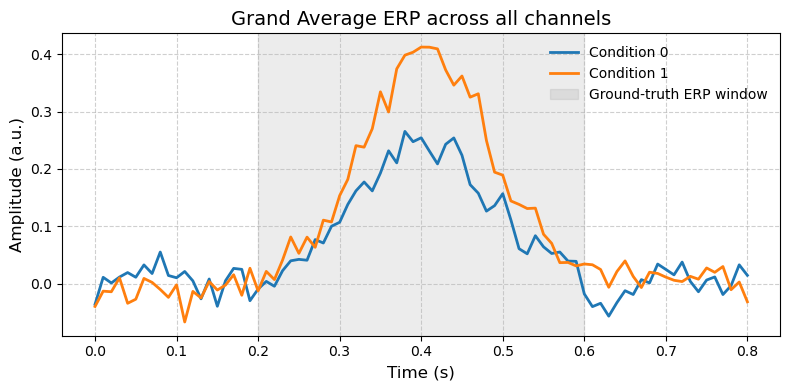

In [4]:
# Calculate the Grand Average ERP per condition
# Mean across trials (axis=0), then mean across channels (axis=0)
erp_cond0 = X[y == 0].mean(axis=0).mean(axis=0)  
erp_cond1 = X[y == 1].mean(axis=0).mean(axis=0)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(times, erp_cond0, label="Condition 0", color="#1f77b4", linewidth=2)
plt.plot(times, erp_cond1, label="Condition 1", color="#ff7f0e", linewidth=2)

# Highlight the ground-truth signal injection window
plt.axvspan(0.2, 0.6, color="gray", alpha=0.15, label="Ground-truth ERP window")

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude (a.u.)", fontsize=12)
plt.title("Grand Average ERP across all channels", fontsize=14)
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Step 3: Configuring HeteroRC

HeteroRC acts as a **fixed (untrained) recurrent feature extractor**. To effectively capture multiscale neural dynamics, we must configure its hyperparameters via the `rc_params` dictionary.

Key parameters include:
* **`n_res`**: The number of reservoir units. A standard heuristic is ~10-15x the number of input channels.
* **`tau_mode` & `tau_sigma`**: Controls the log-normal distribution of intrinsic time constants, allowing the reservoir to integrate fast and slow temporal scales.
* **`bidirectional` & `merge_mode`**: To mitigate integration-induced temporal smearing—a common issue in recurrent networks—we process the data bidirectionally. We use multiplicative fusion (`"product"`) to emphasize temporally consistent structures and align decoding peaks precisely with underlying neural events.

In [ ]:
''' HeteroRC time-resolved decoding '''
rc_params = dict(
    n_res=350, # smaller for low SNR or few trials; larger for richer dynamics. Recommendation: ~10x n_channels
    fs=fs,
    spectral_radius=0.95, # Recommendation: 0.8–0.99 [less impactful for decoding results]
    input_scaling=0.5, # May influence results. larger for more non-linear dynamics
    bias_scaling=0.5, # May influence results too.
    tau_mode=0.01,
    tau_sigma=0.8,
    tau_min=0.002,
    tau_max=0.08,
    bidirectional=True,
    merge_mode="product",
)

# parameters for smoothing decision scores
FWHM_MS = 25.0  # 25ms
sigma_points = (FWHM_MS / 2.355 / 1000.0) * fs

## Step 4: Time-Resolved Decoding

We will now project our EEG data into the high-dimensional reservoir space and train a linear readout (`RidgeClassifierCV`) at each individual time point. 

The function `time_resolved_decoding_heterorc` handles the feature projection, robust scaling (computed strictly on the training set to prevent data leakage), and Stratified 5-Fold Cross-Validation. Because we set `smooth_decisions=True`, a slight temporal smoothing is applied to the decision scores prior to calculating the final accuracy.

Projecting data to reservoir space and running time-resolved CV...
Fold 1/5 done. scale=1.93
Fold 2/5 done. scale=1.94
Fold 3/5 done. scale=1.93
Fold 4/5 done. scale=1.93
Fold 5/5 done. scale=1.93

✅ Peak decoding accuracy: 0.933 at 0.410 s


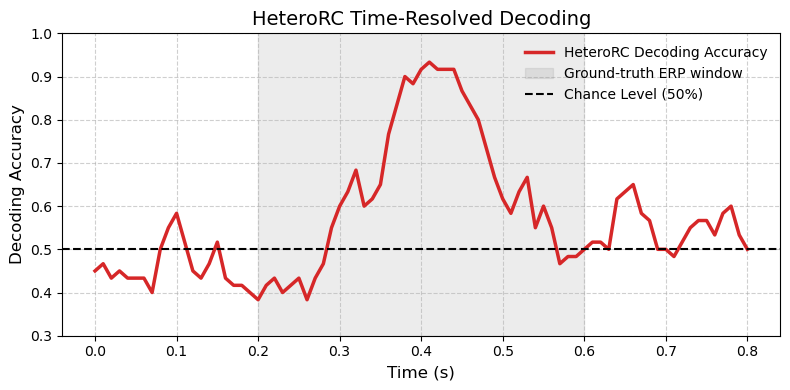

In [ ]:
print("Projecting data to reservoir space and running time-resolved CV...")

# Run the decoding pipeline
accuracy = time_resolved_decoding_heterorc(
    X=X, 
    y=y, 
    times=times,
    n_folds=5,
    rc_params=rc_params,
    metric="accuracy",
    rc_seed_mode="fixed",            # Fixes the reservoir initialization seed across folds
    smooth_decisions=True,
    smooth_sigma_points=sigma_points,
    verbose=True,
)

# Find the peak decoding accuracy and its latency
peak_idx = int(np.argmax(accuracy))
peak_time = float(times[peak_idx])
print(f"\n✅ Peak decoding accuracy: {accuracy[peak_idx]:.3f} at {peak_time:.3f} s")

# Plot the decoding results
plt.figure(figsize=(8, 4))
plt.plot(times, accuracy, color="#d62728", linewidth=2.5, label="HeteroRC Decoding Accuracy")

# Annotations
plt.axvspan(0.2, 0.6, color="gray", alpha=0.15, label="Ground-truth ERP window")
plt.axhline(0.5, linestyle="--", color="black", label="Chance Level (50%)")

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Decoding Accuracy", fontsize=12)
plt.title("HeteroRC Time-Resolved Decoding", fontsize=14)
plt.ylim(0.3, 1.0)
plt.legend(frameon=False, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Step 5: Cross-Temporal Generalization (CTG)

Time-resolved decoding and cross-temporal generalization are now standard tools for characterizing the temporal dynamics of cognitive processes. While the diagonal of a cross-temporal matrix reflects standard time-resolved decoding (training and testing at the same time point), the off-diagonal elements reveal how well a neural representation trained at one moment generalizes to other moments. 

Here, we will use the `cross_temporal_decoding_heterorc` function. It applies the exact same robust scaling, reservoir projection, and temporal smoothing procedures as before, but evaluates the trained linear readout across all testing times to construct a Temporal Generalization Matrix (TGM).

Computing Cross-Temporal Generalization Matrix... This may take a moment.
Fold 1/5 done. scale=1.93
Fold 2/5 done. scale=1.94
Fold 3/5 done. scale=1.93
Fold 4/5 done. scale=1.93
Fold 5/5 done. scale=1.93

✅ Cross-Temporal Generalization completed!


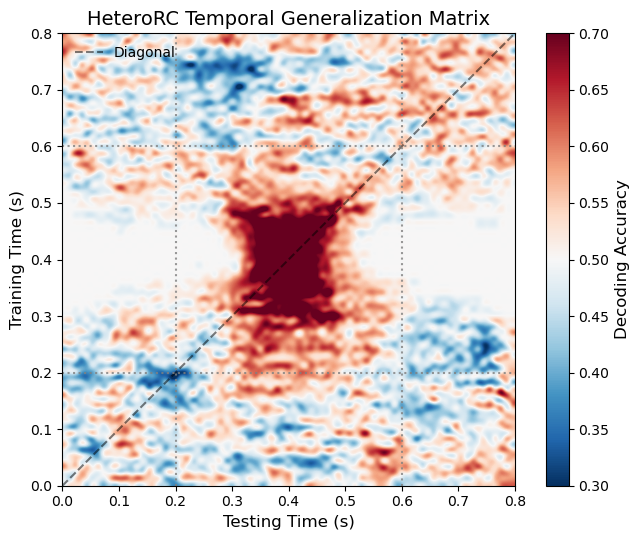

In [9]:
from heterorc import cross_temporal_decoding_heterorc

print("Computing Cross-Temporal Generalization Matrix... This may take a moment.")

# Run cross-temporal generalization
tgm = cross_temporal_decoding_heterorc(
    X=X, 
    y=y, 
    times=times,
    n_folds=5,
    rc_params=rc_params,
    rc_seed_mode="fixed",            # Fixes the reservoir initialization seed across folds
    smooth_decisions=True,
    smooth_sigma_points=sigma_points,
    verbose=True,
)

print("\n✅ Cross-Temporal Generalization completed!")

# Plotting the Temporal Generalization Matrix
plt.figure(figsize=(7, 5.5))

# We use RdBu_r centered around chance level (0.5) for intuitive visualization
im = plt.imshow(
    tgm,
    interpolation="lanczos",
    origin="lower",
    cmap="RdBu_r",
    extent=[times[0], times[-1], times[0], times[-1]],
    vmin=0.3, 
    vmax=0.7
)

# Add a colorbar
cbar = plt.colorbar(im)
cbar.set_label("Decoding Accuracy", fontsize=12)

# Plot the diagonal line (standard time-resolved decoding)
plt.plot([times[0], times[-1]], [times[0], times[-1]], color="black", linestyle="--", alpha=0.5, label="Diagonal")

# Highlight the ERP injection window
plt.axvline(0.2, color="gray", linestyle=":", alpha=0.8)
plt.axvline(0.6, color="gray", linestyle=":", alpha=0.8)
plt.axhline(0.2, color="gray", linestyle=":", alpha=0.8)
plt.axhline(0.6, color="gray", linestyle=":", alpha=0.8)

plt.xlabel("Testing Time (s)", fontsize=12)
plt.ylabel("Training Time (s)", fontsize=12)
plt.title("HeteroRC Temporal Generalization Matrix", fontsize=14)
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Step 6: Cross-Task / Cross-Session Generalization (Independent Train & Test Sets)

In many experimental designs, such as Brain-Computer Interfaces (BCI) or cross-task generalization studies, we need to train a model on one dataset and test it on a completely independent dataset (e.g., recorded on a different day or during a different task condition). 

To support these rigorous evaluations, HeteroRC provides dedicated functions:
* `time_resolved_decoding_train_test_heterorc`
* `cross_generalisation_train_test_heterorc`

In this step, we will simulate another scenario: **Induced Oscillatory Power**. Unlike the ERPs we simulated earlier, induced activity consists of oscillatory power (here, at 10 Hz) where the phase is randomized across trials.

We will:
1. Generate an independent **Training Set** and **Testing Set** featuring 10 Hz induced activity.
2. Use `cross_generalisation_train_test_heterorc` to compute the Temporal Generalization Matrix (TGM).
3. Extract the diagonal of the TGM to display the standard time-resolved decoding performance.

In [10]:
print("Simulating independent Training and Testing sets for Induced 10 Hz activity...")

# Generate Training Set
X_train, y_train, times = simulate_data(
    sub_id=10,             # Different seed for train
    mode='induced',        # Induced oscillatory power
    target_freq=10.0,      # 10 Hz (Alpha band)
    sfreq=100,
    tmin=0.0,
    tmax=0.8,
    n_trials=80,       
    n_channels=32,
    n_classes=2
)

# Generate Testing Set
X_test, y_test, _ = simulate_data(
    sub_id=20,             # Different seed for test
    mode='induced',        # Induced oscillatory power
    target_freq=10.0,      # 10 Hz
    sfreq=100,
    tmin=0.0,
    tmax=0.8,
    n_trials=80,       
    n_channels=32,
    n_classes=2
)

print(f"Train Set: X {X_train.shape}, y {y_train.shape}")
print(f"Test Set:  X {X_test.shape}, y {y_test.shape}")

Simulating independent Training and Testing sets for Induced 10 Hz activity...
Train Set: X (80, 32, 81), y (80,)
Test Set:  X (80, 32, 81), y (80,)


### Sanity Check: Power Spectral Density (PSD)

Unlike ERPs, induced oscillatory activity is non-phase-locked. If we were to simply average the raw signals across trials in the time domain, the random phases would cause the signals to cancel each other out, making the 10 Hz burst invisible. 

Instead, we must perform our sanity check in the **frequency domain**. We will extract the exact signal injection window (`0.2s - 0.6s`) and compute the Power Spectral Density (PSD) using Welch's method. We expect to see a clear power difference around 10 Hz (Alpha band) between the two conditions.

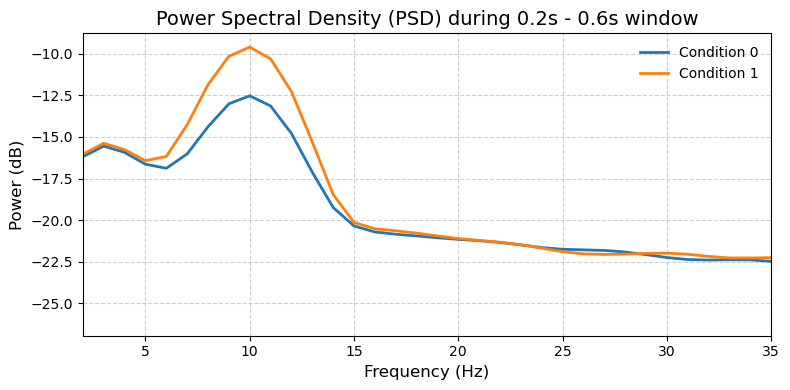

In [14]:
from scipy.signal import welch

# 1. Define the temporal mask for the 0.2 - 0.6s window
target_mask = (times >= 0.2) & (times <= 0.6)

# 2. Extract data strictly within this window
X_train_window = X_train[:, :, target_mask]

# 3. Compute PSD using Welch's method 
# We use nperseg=40 (length of our 0.4s window at 100Hz) and zero-pad via nfft=100 for 1Hz frequency resolution
freqs, psd = welch(X_train_window, fs=100, nperseg=40, nfft=100, axis=-1)

# 4. Average PSD across trials and channels for each condition
# psd shape: (n_trials, n_channels, n_freqs) -> mean across axis 0 and 1
mean_psd_cond0 = psd[y_train == 0].mean(axis=(0, 1))
mean_psd_cond1 = psd[y_train == 1].mean(axis=(0, 1))

# 5. Plot the PSD
plt.figure(figsize=(8, 4))
plt.plot(freqs, 10 * np.log10(mean_psd_cond0), label="Condition 0", color="#1f77b4", linewidth=2)
plt.plot(freqs, 10 * np.log10(mean_psd_cond1), label="Condition 1", color="#ff7f0e", linewidth=2)

plt.xlim(2, 35)  # Focus on the physiologically relevant frequency range (2-35 Hz)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Power (dB)", fontsize=12)
plt.title("Power Spectral Density (PSD) during 0.2s - 0.6s window", fontsize=14)
plt.legend(frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Running Cross-Generalization

We will now apply `cross_generalisation_train_test_heterorc`. This function handles the robust scaling based *only* on the training set to prevent data leakage, initializes a single fixed reservoir shared across both sets, and computes the complete TGM.

In [11]:
from heterorc import cross_generalisation_train_test_heterorc

print("Running Train-Test Cross-Temporal Generalization...")

# Compute the TGM between the training and testing sets
tgm_induced = cross_generalisation_train_test_heterorc(
    X_train=X_train, 
    y_train=y_train,
    X_test=X_test, 
    y_test=y_test,
    times=times,
    rc_params=rc_params,             # Reusing the reservoir parameters from Step 3
    rc_random_state=42,              # Fixed reservoir seed for consistent train/test mapping
    smooth_decisions=True,
    smooth_sigma_points=sigma_points,
    verbose=True
)

# Extract the diagonal for time-resolved decoding (Training Time == Testing Time)
time_resolved_acc = np.diag(tgm_induced)

print("\n✅ Train-Test Decoding completed!")

Running Train-Test Cross-Temporal Generalization...
[Train->Test CTG] scale=2.08, n_train=80, n_test=80, n_times=81
  train_time 1/81 done
  train_time 51/81 done
  train_time 81/81 done

✅ Train-Test Decoding completed!


### Visualizing the Results

We will plot both the full Temporal Generalization Matrix and the extracted diagonal (Time-Resolved Decoding). You will see that HeteroRC successfully captures the 10 Hz non-phase-locked dynamics, which would otherwise be invisible to standard raw-amplitude decoders.

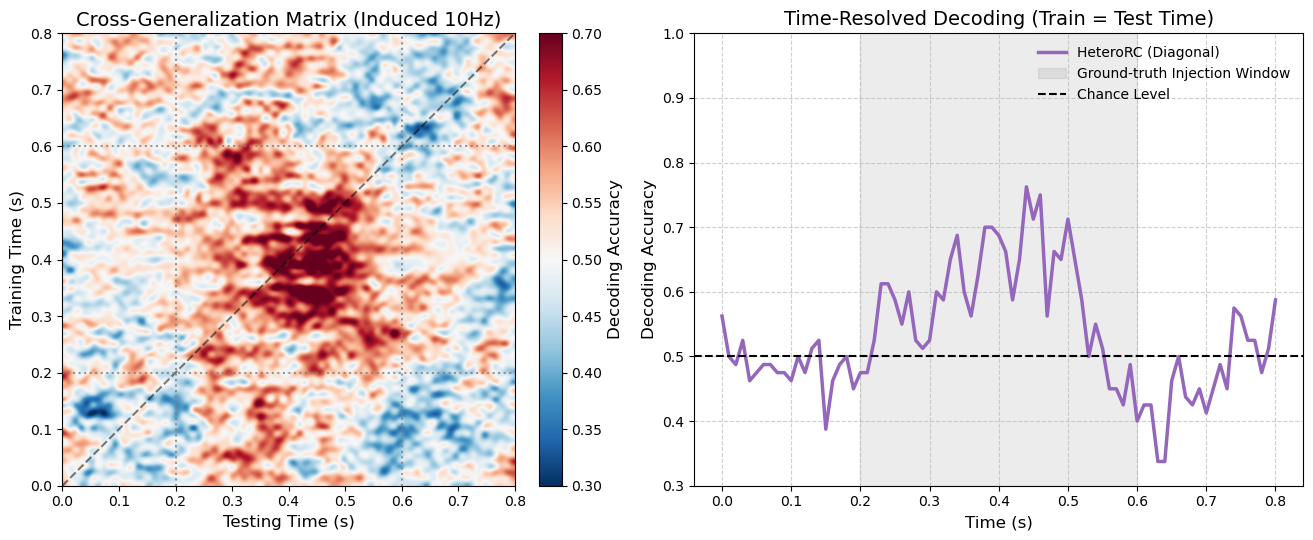

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel 1: Temporal Generalization Matrix ---
im = axes[0].imshow(
    tgm_induced,
    interpolation="lanczos",
    origin="lower",
    cmap="RdBu_r",
    extent=[times[0], times[-1], times[0], times[-1]],
    vmin=0.3, 
    vmax=0.7
)
cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label("Decoding Accuracy", fontsize=12)

axes[0].plot([times[0], times[-1]], [times[0], times[-1]], color="black", linestyle="--", alpha=0.5)
axes[0].axvline(0.2, color="gray", linestyle=":", alpha=0.8)
axes[0].axvline(0.6, color="gray", linestyle=":", alpha=0.8)
axes[0].axhline(0.2, color="gray", linestyle=":", alpha=0.8)
axes[0].axhline(0.6, color="gray", linestyle=":", alpha=0.8)

axes[0].set_xlabel("Testing Time (s)", fontsize=12)
axes[0].set_ylabel("Training Time (s)", fontsize=12)
axes[0].set_title("Cross-Generalization Matrix (Induced 10Hz)", fontsize=14)

# --- Panel 2: Extracted Time-Resolved Decoding (Diagonal) ---
axes[1].plot(times, time_resolved_acc, color="#9467bd", linewidth=2.5, label="HeteroRC (Diagonal)")
axes[1].axvspan(0.2, 0.6, color="gray", alpha=0.15, label="Ground-truth Injection Window")
axes[1].axhline(0.5, linestyle="--", color="black", label="Chance Level")

axes[1].set_xlabel("Time (s)", fontsize=12)
axes[1].set_ylabel("Decoding Accuracy", fontsize=12)
axes[1].set_title("Time-Resolved Decoding (Train = Test Time)", fontsize=14)
axes[1].set_ylim(0.3, 1.0)
axes[1].legend(frameon=False, loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()